Project

Use the most recent 756 daily returns at each estimate date. Estimate the first weights at the December 31, 2024 close. Re-estimate at each later month-end through June 30, 2026 and hold each weight vector over the following month’s daily returns. Estimate once more on July 31, 2026 for the final allocation decision.

A weight set at the close of date 
 first earns the return on the next trading day. Reset the equal-sleeve comparison on the same month-end dates. Ignore financing costs, transaction costs, taxes, and market impact.

Part 1.1: Verify the equal-sleeve portfolio’s long, short, gross, and net exposures. Report the position in each stock for $100 million of NAV.

In [5]:
import pandas as pd
import numpy as np

FILE = "project_situational_awareness_20260731.xlsx"

baseline = pd.read_excel(
    FILE,
    sheet_name="baseline weights"
)

baseline

,ticker,name,side,equal-sleeve weight
0,SNDK,Sandisk,long,0.333333
1,MU,Micron Technology,long,0.333333
2,VRT,Vertiv,long,0.333333
3,LITE,Lumentum,long,0.333333
4,COHR,Coherent,long,0.333333
5,BE,Bloom Energy,long,0.333333
6,ADBE,Adobe,short,-0.333333
7,CRM,Salesforce,short,-0.333333
8,ORCL,Oracle,short,-0.333333
9,NOW,ServiceNow,short,-0.333333


In [6]:
baseline = baseline.set_index("ticker")

w_equal = baseline["equal-sleeve weight"]

long_exposure = w_equal[w_equal > 0].sum()
short_exposure = w_equal[w_equal < 0].sum()
gross_exposure = w_equal.abs().sum()
net_exposure = w_equal.sum()

print(f"Long exposure:  {long_exposure:.2%}")
print(f"Short exposure: {short_exposure:.2%}")
print(f"Gross exposure: {gross_exposure:.2%}")
print(f"Net exposure:   {net_exposure:.2%}")

Long exposure:  200.00%
Short exposure: -200.00%
Gross exposure: 400.00%
Net exposure:   0.00%


In [11]:
NAV = 100000000 #100 million nav

positions = pd.DataFrame({
    "weight": w_equal,
    "position ($)": NAV * w_equal
})

positions.style.format({
    "weight": "{:.2%}",
    "position ($)": "{:,.2f}"
})

,weight,position ($)
ticker,,
SNDK,33.33%,"33,333,333.33"
MU,33.33%,"33,333,333.33"
VRT,33.33%,"33,333,333.33"
LITE,33.33%,"33,333,333.33"
COHR,33.33%,"33,333,333.33"
BE,33.33%,"33,333,333.33"
ADBE,-33.33%,"-33,333,333.33"
CRM,-33.33%,"-33,333,333.33"
ORCL,-33.33%,"-33,333,333.33"


Part 1.2: Using only returns available through December 31, 2024, report annualized mean, volatility, Sharpe ratio, and the correlation matrix for the 12 stocks. Identify one feature of the estimates that could make an unconstrained optimizer unreliable.

In [14]:
returns = pd.read_excel(
    FILE,
    sheet_name="total returns",
    index_col="Date",
    parse_dates=True
)

stocks = [
    "SNDK", "MU", "VRT", "LITE", "COHR", "BE",
    "ADBE", "CRM", "ORCL", "NOW", "WDAY", "MDB"
]

stock_returns = returns[stocks]

est_returns = stock_returns.loc[: "2024-12-31"].tail(756)

print(est_returns.index.min())
print(est_returns.index.max())
print(len(est_returns))

2021-12-29 00:00:00
2024-12-31 00:00:00
756


In [45]:
#calculate mean, vol, sharpe, stats
ann_mean = est_returns.mean() * 252
ann_vol = est_returns.std() * np.sqrt(252)
sharpe = ann_mean / ann_vol

#make dataframe of stats and display
stats = pd.DataFrame({
    "Annualized Mean": ann_mean,
    "Annualized Volatility": ann_vol,
    "Sharpe Ratio": sharpe
})
stats

,Annualized Mean,Annualized Volatility,Sharpe Ratio
SNDK,0.069359,0.417826,0.166001
MU,0.077045,0.455510,0.169139
VRT,0.711837,0.628390,1.132795
LITE,0.038393,0.480180,0.079956
COHR,0.269819,0.563573,0.478764
BE,0.306897,0.792823,0.387094
ADBE,-0.008353,0.382094,-0.021860
CRM,0.165476,0.383078,0.431964
ORCL,0.273021,0.309489,0.882167
NOW,0.248302,0.418231,0.593696


In [46]:
#correlation matrix
corr = est_returns.corr()
corr


,SNDK,MU,VRT,LITE,COHR,BE,ADBE,CRM,ORCL,NOW,WDAY,MDB
SNDK,1.000000,0.718547,0.438887,0.466519,0.490183,0.323291,0.407412,0.384610,0.339325,0.350159,0.297831,0.355324
MU,0.718547,1.000000,0.434841,0.469929,0.501027,0.314554,0.410147,0.400437,0.367142,0.384250,0.358434,0.363191
VRT,0.438887,0.434841,1.000000,0.407463,0.452319,0.303347,0.377112,0.397865,0.387464,0.421893,0.315579,0.401031
LITE,0.466519,0.469929,0.407463,1.000000,0.646837,0.306949,0.353031,0.403897,0.338876,0.365479,0.350723,0.331929
COHR,0.490183,0.501027,0.452319,0.646837,1.000000,0.293910,0.363246,0.363704,0.361128,0.377299,0.339895,0.362253
BE,0.323291,0.314554,0.303347,0.306949,0.293910,1.000000,0.252420,0.284910,0.234755,0.303490,0.279246,0.333016
ADBE,0.407412,0.410147,0.377112,0.353031,0.363246,0.252420,1.000000,0.610672,0.447802,0.650351,0.555527,0.508431
CRM,0.384610,0.400437,0.397865,0.403897,0.363704,0.284910,0.610672,1.000000,0.411900,0.713163,0.617409,0.502621
ORCL,0.339325,0.367142,0.387464,0.338876,0.361128,0.234755,0.447802,0.411900,1.000000,0.469581,0.372138,0.348297
NOW,0.350159,0.384250,0.421893,0.365479,0.377299,0.303490,0.650351,0.713163,0.469581,1.000000,0.643205,0.626946


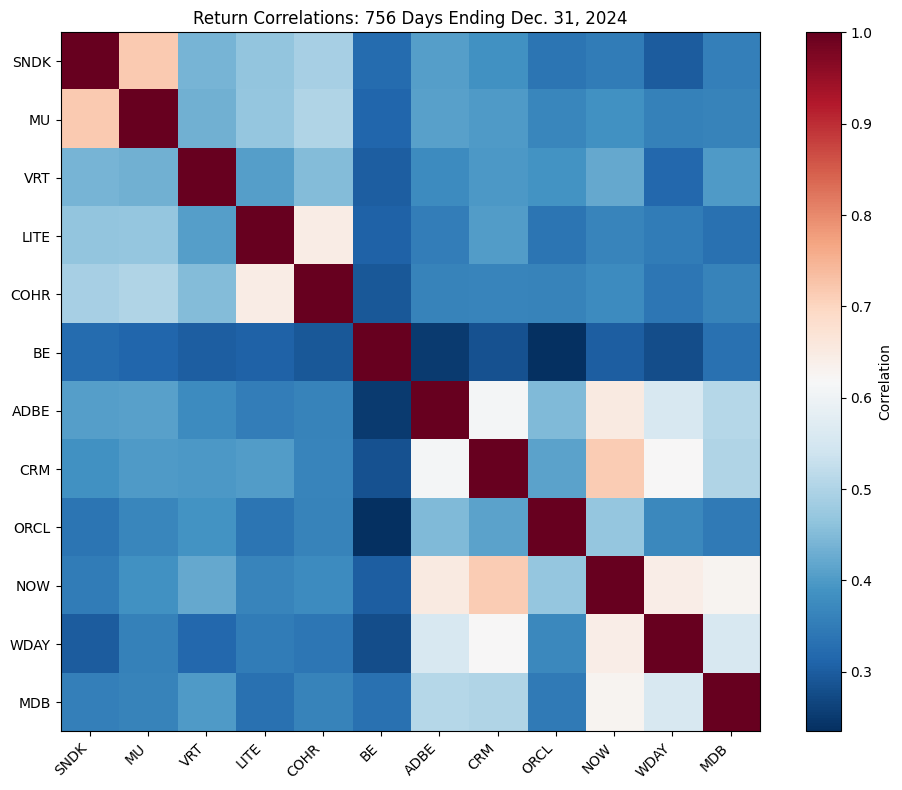

In [48]:
#make heatmap
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr, cmap="RdBu_r")

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")

ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Return Correlations: 756 Days Ending Dec. 31, 2024")

plt.tight_layout()
plt.show()

In [49]:
#check matrix and sharp ratios
print("condition number of covariance matrix:",
      np.linalg.cond(est_returns.cov()))
stats.sort_values("Sharpe Ratio", ascending=False)

condition number of covariance matrix: 34.73085258380912


,Annualized Mean,Annualized Volatility,Sharpe Ratio
VRT,0.711837,0.628390,1.132795
ORCL,0.273021,0.309489,0.882167
NOW,0.248302,0.418231,0.593696
COHR,0.269819,0.563573,0.478764
CRM,0.165476,0.383078,0.431964
BE,0.306897,0.792823,0.387094
MU,0.077045,0.455510,0.169139
SNDK,0.069359,0.417826,0.166001
WDAY,0.053802,0.391505,0.137425
LITE,0.038393,0.480180,0.079956


On optimizer unreliability:

The estimates contain substantial estimation risk in the sample means. Expected returns are estimated from only daily observations and can differ materially across stocks due to a lot of sampling noise. Because the tangency portfolio depends directly on the sample mean, small errors in estimated means or covariances can translate into very large and unstable portfolio weights. This makes an unconstrained optimizer particularly vulnerable to extreme positions. Small changes in an estimated expected return can cause enormous changes in optimal weights, particularly when securities are correlated.

Part 2.1: Used position cap stabilizer, which uses the sample mean and covariance matrix. We added constraints and boundaries so that the absolute positions are no more than 50% of NAV. 

The portfolio maximizes its estimated Sharpe ratio using the sample mean and covariance matrix from the daily returns ending 12/31/2024 and 0 risk-free rate. The position cap is intended to reduce sensitivity to noisy expected-return and covariance estimates by preventing the optimizer from concentrating excessively in securities that appear unusually attractive in-sample.

In [24]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd

# Estimates from the 756 days ending 2024-12-31
mu = est_returns.mean() * 252
Sigma = est_returns.cov() * 252

stocks = list(est_returns.columns)

long_tickers = ["SNDK", "MU", "VRT", "LITE", "COHR", "BE"]
short_tickers = ["ADBE", "CRM", "ORCL", "NOW", "WDAY", "MDB"]

long_idx = [stocks.index(t) for t in long_tickers]
short_idx = [stocks.index(t) for t in short_tickers]

#define negative sharpe
def neg_sharpe(w, mu, Sigma):
    port_mean = w @ mu
    port_vol = np.sqrt(w @ Sigma @ w)
    return -port_mean / port_vol

#equal sleeve portfolio
x0 = w_equal.reindex(stocks).values

#add constriants and bounds
constraints = [
    {
        "type": "eq",
        "fun": lambda w: w[long_idx].sum() - 2
    },
    {
        "type": "eq",
        "fun": lambda w: w[short_idx].sum() + 2
    }
]

bounds = [
    (0, 0.5) if ticker in long_tickers
    else (-0.5, 0)
    for ticker in stocks
]

#generate minimized result
result = minimize(
    neg_sharpe,
    x0,
    args=(mu.values, Sigma.values),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "ftol": 1e-12,
        "maxiter": 1000
    }
)

#check success
print("success?", result.success)
print("msg", result.message)

#get weights
w_opt = pd.Series(
    result.x,
    index=stocks,
    name="optimized weight"
)

w_opt

success? True
msg Optimization terminated successfully


SNDK    1.969018e-01
MU      3.030982e-01
VRT     5.000000e-01
LITE    4.160333e-16
COHR    5.000000e-01
BE      5.000000e-01
ADBE   -5.000000e-01
CRM    -5.000000e-01
ORCL   -1.694426e-17
NOW    -3.283398e-17
WDAY   -5.000000e-01
MDB    -5.000000e-01
Name: optimized weight, dtype: float64

In [25]:
#check exposures
long_exposure = w_opt[w_opt > 0].sum()
short_exposure = w_opt[w_opt < 0].sum()
gross_exposure = w_opt.abs().sum()
net_exposure = w_opt.sum()
largest_position = w_opt.abs().max()

print(f"Long exposure:    {long_exposure:.6f}")
print(f"Short exposure:   {short_exposure:.6f}")
print(f"Gross exposure:   {gross_exposure:.6f}")
print(f"Net exposure:     {net_exposure:.6f}")
print(f"Largest position: {largest_position:.6f}")

Long exposure:    2.000000
Short exposure:   -2.000000
Gross exposure:   4.000000
Net exposure:     0.000000
Largest position: 0.500000


In [27]:
#verification

tol = 1e-8

checks = {
    "optimizer succeeded": result.success,
    "long exposure = +2": np.isclose(
        w_opt.loc[long_tickers].sum(), 2, atol=tol
    ),
    "short exposure = -2": np.isclose(
        w_opt.loc[short_tickers].sum(), -2, atol=tol
    ),
    "gross exposure = 4": np.isclose(
        w_opt.abs().sum(), 4, atol=tol
    ),
    "net exposure = 0": np.isclose(
        w_opt.sum(), 0, atol=tol
    ),
    "position cap satisfied": (w_opt.abs() <= 0.5 + tol).all()
}

pd.Series(checks)

optimizer succeeded       True
long exposure = +2        True
short exposure = -2       True
gross exposure = 4        True
net exposure = 0          True
position cap satisfied    True
dtype: bool

In [ ]:
#check portfolio stats
def portfolio_stats(w, mu, Sigma):
    mean = w @ mu
    vol = np.sqrt(w @ Sigma @ w)
    sharpe = mean / vol
    return mean, vol, sharpe

eq_mean, eq_vol, eq_sharpe = portfolio_stats(
    x0, mu.values, Sigma.values
)

opt_mean, opt_vol, opt_sharpe = portfolio_stats(
    result.x, mu.values, Sigma.values
)

print(f"Equal-sleeve estimated Sharpe: {eq_sharpe:.3f}")
print(f"Optimized estimated Sharpe:    {opt_sharpe:.3f}")

Equal-sleeve estimated Sharpe: 0.392
Optimized estimated Sharpe:    0.778


Part 2.2 Numeric Pass Fail Criteria

1. Pass if annualized one-way turnover is no greater than 300% of NAV
- One way turnover is total buys or total sells, defined as 1/2 the sum of weight changes
- Passes if its annualized one-way turnover < 300% NAV. This corresponds to average monthly turnover of 25% of NAV. Because the optimization is re-estimated monthly from noisy historical estimates, substantially higher turnover would show optimizer reacting excessively to small changes in estimated inputs rather than producing a stable allocation.


2. Pass if its realized out-of-sample Sharpe exceeds the equal-sleeve Sharpe by at least 0.20
- Passes if SR(test) - SR(equal) >= 0.2
- Passes if realized Sharpe ratio from the post-2024 test period > the equal-sleeve portfolio's Sharpe ratio by at least 0.20. Because the optimizer explicitly maximizes estimated Sharpe ratio, its out-of-sample success should be judged on the same risk-adjusted basis. Requiring a 0.20 improvement makes sure evidence of optimization materially improved the portfolio.


Conclusion: Ex-ante replacement criteria. Before examining any portfolio returns after 12/31/2024 we specify two criteria for replacing the equal-sleeve allocation. First, the optimized portfolio must have annualized one-way turnover no greater than 300% of NAV. Second, its realized post-2024 Sharpe ratio must exceed that of the equal-sleeve portfolio by at least 0.20. We will recommend replacing the old portfolio only if both criteria are satisfied.

Part 3.1: Use the 756 returns ending December 31, 2024 to estimate the optimized weights. Compare them with equal sleeves. Report long, short, gross, and net exposure; the largest absolute position; and the estimated annualized mean, volatility, and Sharpe ratio.

In [28]:
#comparison table of optimized weights
comparison = pd.DataFrame({
    "Equal Sleeve": w_equal.reindex(stocks),
    "Optimized": w_opt
})

comparison["Change"] = comparison["Optimized"] - comparison["Equal Sleeve"]

display(
    comparison.style.format({
        "Equal Sleeve": "{:.2%}",
        "Optimized": "{:.2%}",
        "Change": "{:+.2%}"
    })
)

,Equal Sleeve,Optimized,Change
SNDK,33.33%,19.69%,-13.64%
MU,33.33%,30.31%,-3.02%
VRT,33.33%,50.00%,+16.67%
LITE,33.33%,0.00%,-33.33%
COHR,33.33%,50.00%,+16.67%
BE,33.33%,50.00%,+16.67%
ADBE,-33.33%,-50.00%,-16.67%
CRM,-33.33%,-50.00%,-16.67%
ORCL,-33.33%,-0.00%,+33.33%
NOW,-33.33%,-0.00%,+33.33%


In [ ]:
#exposure checks
long_exposure = w_opt.loc[long_tickers].sum()
short_exposure = w_opt.loc[short_tickers].sum()
gross_exposure = w_opt.abs().sum()
net_exposure = w_opt.sum()
largest_position = w_opt.abs().max()
largest_ticker = w_opt.abs().idxmax()

print(f"Long exposure:       {long_exposure:.2%}")
print(f"Short exposure:      {short_exposure:.2%}")
print(f"Gross exposure:      {gross_exposure:.2%}")
print(f"Net exposure:        {net_exposure:.2%}")
print(f"Largest absolute position:    {largest_position:.2%} ({largest_ticker})")

Long exposure:       200.00%
Short exposure:      -200.00%
Gross exposure:      400.00%
Net exposure:        0.00%
Largest position:    50.00% (BE)


In [ ]:
#estimated portfolio stats comparison

eq_mean, eq_vol, eq_sharpe = portfolio_stats(
    w_equal.reindex(stocks).values,
    mu.values,
    Sigma.values
)

opt_mean, opt_vol, opt_sharpe = portfolio_stats(
    w_opt.values,
    mu.values,
    Sigma.values
)

#original
print("Equal sleeves")
print(f"Annualized mean: {eq_mean:.2%}")
print(f"Annualized vol:  {eq_vol:.2%}")
print(f"Sharpe:          {eq_sharpe:.3f}")

#optimized
print("\nOptimized")
print(f"Annualized mean: {opt_mean:.2%}")
print(f"Annualized vol:  {opt_vol:.2%}")
print(f"Sharpe:          {opt_sharpe:.3f}")

Equal sleeves
Annualized mean: 25.76%
Annualized vol:  65.67%
Sharpe:          0.392

Optimized
Annualized mean: 59.17%
Annualized vol:  76.10%
Sharpe:          0.778


Part 3.2: Identify the two largest changes from equal sleeves. Trace each change to estimated mean, volatility, or covariance rather than describing the company alone.

In [ ]:
top2 = comparison["Change"].abs().nlargest(3).index
#there is actually a tie for top 2, with ORCL NOW and LITE all changing 33.33pp, so I chose to show all three here

explanation_table = pd.DataFrame({
    "Equal Weight": w_equal.reindex(stocks),
    "Optimized Weight": w_opt,
    "Change": w_opt - w_equal.reindex(stocks),
    "Annualized Mean": mu,
    "Annualized Volatility": np.sqrt(np.diag(Sigma)),
    "Sharpe": mu / np.sqrt(np.diag(Sigma))
}).loc[top2]

explanation_table

,Equal Weight,Optimized Weight,Change,Annualized Mean,Annualized Volatility,Sharpe
ORCL,-0.333333,-1.694426e-17,0.333333,0.273021,0.309489,0.882167
NOW,-0.333333,-3.283398e-17,0.333333,0.248302,0.418231,0.593696
LITE,0.333333,4.160333e-16,-0.333333,0.038393,0.480180,0.079956


In [43]:
#diagnostics table
diagnostics = comparison.copy()

diagnostics["Annualized Mean"] = mu
diagnostics["Annualized Vol"] = np.sqrt(np.diag(Sigma))

diagnostics = diagnostics.loc[
    diagnostics["Change"].abs().sort_values(ascending=False).index
]

diagnostics


,Equal Sleeve,Optimized,Change,Annualized Mean,Annualized Vol
ORCL,-0.333333,-1.694426e-17,0.333333,0.273021,0.309489
NOW,-0.333333,-3.283398e-17,0.333333,0.248302,0.418231
LITE,0.333333,4.160333e-16,-0.333333,0.038393,0.480180
BE,0.333333,5.000000e-01,0.166667,0.306897,0.792823
CRM,-0.333333,-5.000000e-01,-0.166667,0.165476,0.383078
WDAY,-0.333333,-5.000000e-01,-0.166667,0.053802,0.391505
COHR,0.333333,5.000000e-01,0.166667,0.269819,0.563573
ADBE,-0.333333,-5.000000e-01,-0.166667,-0.008353,0.382094
MDB,-0.333333,-5.000000e-01,-0.166667,-0.031711,0.707892
VRT,0.333333,5.000000e-01,0.166667,0.711837,0.628390


In [44]:
#look at correlation of our top 2
corr.loc[top2]

,SNDK,MU,VRT,LITE,COHR,BE,ADBE,CRM,ORCL,NOW,WDAY,MDB
ORCL,0.339325,0.367142,0.387464,0.338876,0.361128,0.234755,0.447802,0.411900,1.000000,0.469581,0.372138,0.348297
NOW,0.350159,0.384250,0.421893,0.365479,0.377299,0.303490,0.650351,0.713163,0.469581,1.000000,0.643205,0.626946
LITE,0.466519,0.469929,0.407463,1.000000,0.646837,0.306949,0.353031,0.403897,0.338876,0.365479,0.350723,0.331929


ORCL: goes from −33.33% to ~0%. Its estimated annual mean return is +27.30% with annualized volatility of only 30.95%, producing a standalone Sharpe ratio of 0.88. Because ORCL belongs to the short sleeve, this strongly positive estimated return makes a negative ORCL weight unattractive: the short position would reduce the portfolio's estimated expected return. The optimizer therefore eliminates the ORCL short and shifts the required −200% short exposure toward securities with less favorable estimated return distributions.

NOW: similarly to ORCL, went from -33.33% to ~0%. It's estimated annual mean return is +24.83% with volatility of 41.82% producing a sharpe of 0.59, and its correlations with the other software shorts like CRM, ADBE, WDAY, etc.. are pretty high. Thus the optimizer removes it.

LITE: on the long side, this goes from +33.33% to 0%. Its estimated annual return is only 3.84% despite annualized volatility of 48.02%, giving it a standalone Sharpe ratio of just 0.08. Relative to other long-side securities, the estimated return does not compensate for its risk, so the optimizer removes the position and reallocates the long sleeve toward securities with more favorable estimated mean-risk combinations.